# 03b Figuras finales del Hito 1

**Proyecto:** accesibilidad peatonal a equipamiento urbano – Miraflores + San Juan de Miraflores (Hito 1)

Completa las figuras del paso 9 del plan. Las demás ya se generaron en `03_metricas_y_eda` (prefijos `eda_` y `metricas_`). Este notebook agrega:

| Figura | Archivo |
|---|---|
| Área de estudio con zona del grafo, zona de POI, parques y barreras físicas | `figures/maps/hito1_01_area_estudio.png` |
| Datos faltantes por atributo y distrito | `figures/plots/hito1_08_datos_faltantes.png` |
| Isócrona de prueba (5, 10 y 15 min) desde un hospital | `figures/maps/hito1_09_isocrona_prueba.png` |

Los pies de figura de todas están en `figures/CATALOGO.md`. Trabaja sin red.

## 1. Carga

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import osmnx as ox
import pyogrio
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

sys.path.insert(0, str(Path.cwd().parent))
from src import config as cfg
from src import mapas, red

np.random.seed(cfg.SEED)
plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False})
DISTRITOS = cfg.DISTRICT_LABELS
COLOR_D = {"Miraflores": "#1f77b4", "San Juan de Miraflores": "#e08a1e"}
FUENTE = "Fuente: © OpenStreetMap contributors. CRS: EPSG:32718."

G = ox.load_graphml(cfg.DATA_INTERIM / "walk_graph_clean.graphml")
limites_utm = gpd.read_file(cfg.DATA_RAW / "limites_distritos.gpkg").to_crs(cfg.CRS_METRIC)
poi = pd.read_csv(cfg.DATA_PROCESSED / "poi_snap.csv")
poi = poi[poi["snap_valido"]].copy()

union = limites_utm.geometry.union_all()
zona_grafo = gpd.GeoSeries([union.buffer(cfg.BUFFER_M)], crs=cfg.CRS_METRIC)
zona_poi = gpd.GeoSeries([union.buffer(cfg.POI_BUFFER_M)], crs=cfg.CRS_METRIC)

# Capas de contexto descargadas en 02a
ruta_poi = cfg.DATA_RAW / "poi_osm.gpkg"
def capa(nombre):
    partes = [gpd.read_file(ruta_poi, layer=l) for l, _ in pyogrio.list_layers(ruta_poi) if l.startswith(nombre + "_")]
    return pd.concat(partes, ignore_index=True).pipe(gpd.GeoDataFrame, crs=4326).to_crs(cfg.CRS_METRIC)

parques = capa("parques")
parques = parques[parques.geom_type.str.contains("Polygon")]
barreras = capa("barreras")
def tiene(col):   # una columna puede faltar si OSM no trae ese tipo de elemento en la zona
    return barreras[col].notna() if col in barreras else pd.Series(False, index=barreras.index)
barreras["tipo"] = np.select([tiene("railway"), tiene("waterway"), tiene("highway")],
                             ["Ferrocarril", "Río o canal", "Vía rápida (trunk/motorway)"], default="Otra")
print(f"Parques: {len(parques)} | barreras: {barreras['tipo'].value_counts().to_dict()}")

Parques: 967 | barreras: {'Vía rápida (trunk/motorway)': 180}


## 2. Figura: área de estudio

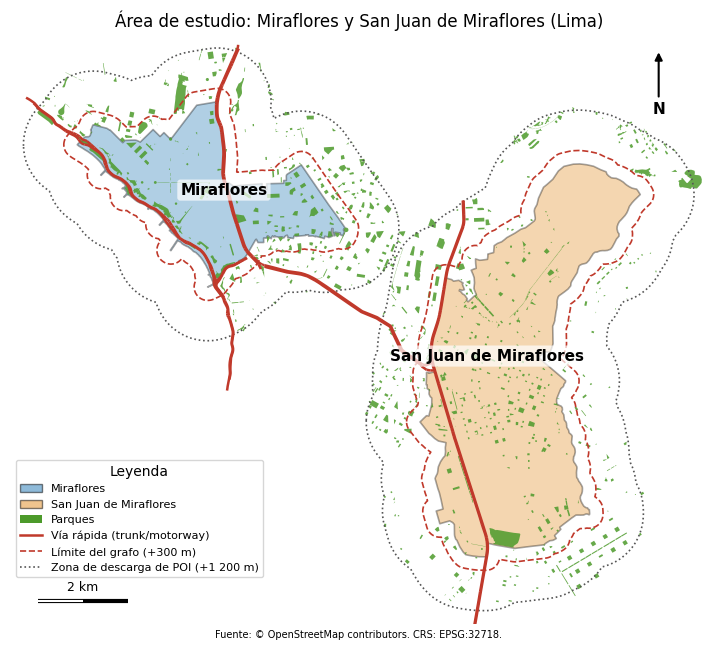

In [2]:
fig, ax = plt.subplots(figsize=(9, 9))
zona_poi.boundary.plot(ax=ax, color="#555555", linestyle=":", linewidth=1.2)
zona_grafo.boundary.plot(ax=ax, color="#c0392b", linestyle="--", linewidth=1.2)
limites_utm.plot(ax=ax, color=[COLOR_D[d] for d in limites_utm["distrito"]], alpha=0.35, edgecolor="k", linewidth=1.2)
parques[parques.intersects(zona_poi.iloc[0])].plot(ax=ax, color="#4c9a2a", alpha=0.85)
ESTILO_B = {"Ferrocarril": ("#222222", 1.6, "-"), "Río o canal": ("#2e86c1", 1.6, "-"), "Vía rápida (trunk/motorway)": ("#c0392b", 1.8, "-")}
presentes = [t for t in ESTILO_B if (barreras["tipo"] == t).any()]
for tipo in presentes:
    color, lw, ls = ESTILO_B[tipo]
    barreras[barreras["tipo"] == tipo].plot(ax=ax, color=color, linewidth=lw, linestyle=ls)
for _, f in limites_utm.iterrows():
    p = f.geometry.representative_point()
    ax.annotate(f["distrito"], (p.x, p.y), ha="center", fontsize=11, fontweight="bold", color="k",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7))
xmin, ymin, xmax, ymax = zona_poi.total_bounds
ax.set_xlim(xmin - 300, xmax + 300)
ax.set_ylim(ymin - 300, ymax + 300)
ax.set_axis_off()
mapas.escala_y_norte(ax, 2000)
ax.legend(handles=[
    Patch(fc=COLOR_D["Miraflores"], alpha=0.5, ec="k", label="Miraflores"),
    Patch(fc=COLOR_D["San Juan de Miraflores"], alpha=0.5, ec="k", label="San Juan de Miraflores"),
    Patch(fc="#4c9a2a", label="Parques"),
    *[Line2D([0], [0], color=ESTILO_B[t][0], lw=ESTILO_B[t][1], label=t) for t in presentes],
    Line2D([0], [0], color="#c0392b", lw=1.2, ls="--", label=f"Límite del grafo (+{cfg.BUFFER_M} m)"),
    Line2D([0], [0], color="#555555", lw=1.2, ls=":", label=f"Zona de descarga de POI (+{cfg.POI_BUFFER_M:,} m)".replace(",", " ")),
], loc="lower left", bbox_to_anchor=(0.0, 0.07), fontsize=8, frameon=True, title="Leyenda")
ax.set_title("Área de estudio: Miraflores y San Juan de Miraflores (Lima)")
ax.text(0.5, -0.01, FUENTE, transform=ax.transAxes, ha="center", va="top", fontsize=7)
mapas.guardar(fig, cfg.FIG_MAPS / "hito1_01_area_estudio.png")
plt.show()

## 3. Figura: datos faltantes

Porcentaje de aristas sin `name`, `maxspeed` y `lanes` en el grafo limpio. Cada arista se asigna al distrito que contiene su punto medio. Un valor tipo lista cuenta como presente. El enunciado pide reportar este porcentaje y explicar cómo se trata: **no se imputa**, porque el análisis peatonal usa una velocidad de caminata constante y estos atributos no entran en el cálculo.

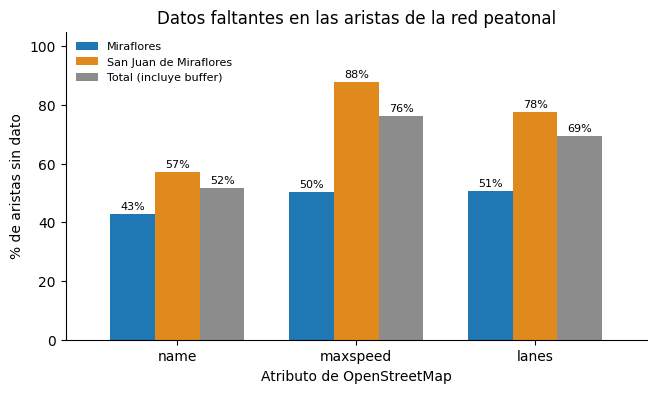

,Miraflores,San Juan de Miraflores,Total (incluye buffer)
name,42.9,57.2,51.8
maxspeed,50.2,87.9,76.3
lanes,50.7,77.6,69.3


In [3]:
aristas = ox.graph_to_gdfs(G, nodes=False).reset_index()
medio = gpd.GeoDataFrame(geometry=aristas.geometry.interpolate(0.5, normalized=True), crs=aristas.crs)
j = gpd.sjoin(medio, limites_utm[["distrito", "geometry"]], how="left", predicate="within")
j = j[~j.index.duplicated(keep="first")]
aristas["distrito"] = j["distrito"].fillna("Fuera (buffer)")

ATRIB = ["name", "maxspeed", "lanes"]
faltante = pd.DataFrame({d: aristas.loc[aristas["distrito"] == d, ATRIB].isna().mean() * 100 for d in DISTRITOS})
faltante["Total (incluye buffer)"] = aristas[ATRIB].isna().mean() * 100
faltante.round(1).to_csv(cfg.DATA_PROCESSED / "datos_faltantes_por_distrito.csv")

fig, ax = plt.subplots(figsize=(7.5, 4))
colores = [COLOR_D["Miraflores"], COLOR_D["San Juan de Miraflores"], "#8c8c8c"]
faltante.plot.bar(ax=ax, color=colores, width=0.75, rot=0)
for cont in ax.containers:
    ax.bar_label(cont, fmt="%.0f%%", fontsize=8, padding=2)
ax.set_ylim(0, 105)
ax.set_ylabel("% de aristas sin dato")
ax.set_xlabel("Atributo de OpenStreetMap")
ax.set_title("Datos faltantes en las aristas de la red peatonal")
ax.legend(frameon=False, fontsize=8, loc="upper left")
mapas.guardar(fig, cfg.FIG_PLOTS / "hito1_08_datos_faltantes.png")
plt.show()
faltante.round(1)

## 4. Figura: isócrona de prueba

Nodos alcanzables caminando desde un hospital de Miraflores, a 4.8 km/h (80 m/min): 5 min = 400 m, 10 min = 800 m, 15 min = 1 200 m. Es una prueba del método (el cálculo completo, con cobertura de nodos y superficie, es del Hito 2).

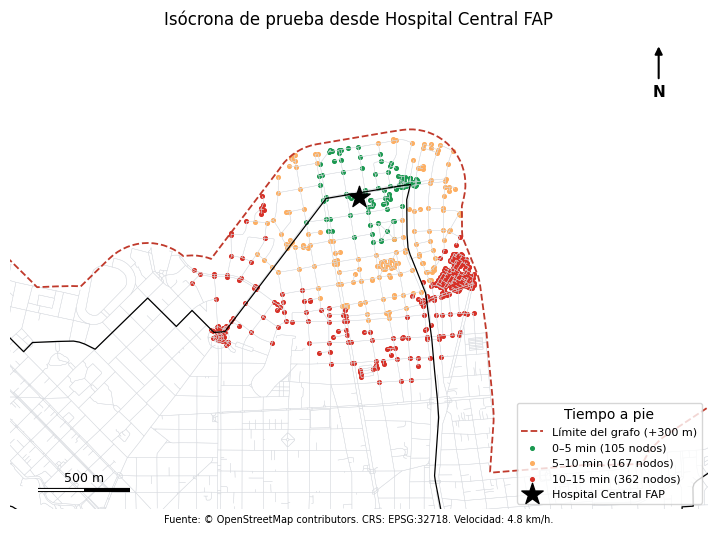

{5: 105, 10: 272, 15: 634}


In [4]:
D = red.construir_digrafo(G, cfg.WALK_SPEED_KMH)
h = poi[(poi["capa"] == "salud") & (poi["categoria"] == "hospital") & (poi["zona"] == "Miraflores")].sort_values("name").iloc[0]
origen = int(h["nodo_osmid"])
t = nx.single_source_dijkstra_path_length(D, origen, cutoff=max(cfg.ISOCHRONE_MINUTES), weight="tiempo_min")

nodos = ox.graph_to_gdfs(G, edges=False)
alc = nodos.loc[list(t)].copy()
alc["minutos"] = pd.Series(t)
alc["banda"] = pd.cut(alc["minutos"], [-0.01, 5, 10, 15], labels=["0–5 min", "5–10 min", "10–15 min"])
COL_B = {"0–5 min": "#1a9850", "5–10 min": "#fdae61", "10–15 min": "#d73027"}

fig, ax = plt.subplots(figsize=(9, 6.6))
aristas.plot(ax=ax, color="#d9dce1", linewidth=0.3)
limites_utm.boundary.plot(ax=ax, color="k", lw=0.9)
zona_grafo.boundary.plot(ax=ax, color="#c0392b", linestyle="--", linewidth=1.3, label=f"Límite del grafo (+{cfg.BUFFER_M} m)")
for banda, color in COL_B.items():
    alc[alc["banda"] == banda].plot(ax=ax, color=color, markersize=7, label=f"{banda} ({(alc['banda'] == banda).sum()} nodos)")
nodos.loc[[origen]].plot(ax=ax, color="k", marker="*", markersize=260, label=h["name"], zorder=6)
x0, y0 = nodos.loc[origen].geometry.x, nodos.loc[origen].geometry.y
ax.set_xlim(x0 - 1900, x0 + 1900)
ax.set_ylim(y0 - 1700, y0 + 900)
ax.set_axis_off()
mapas.escala_y_norte(ax, 500)
ax.legend(loc="lower right", fontsize=8, title="Tiempo a pie", frameon=True)
ax.set_title(f"Isócrona de prueba desde {h['name']}")
ax.text(0.5, -0.01, FUENTE + " Velocidad: 4.8 km/h.", transform=ax.transAxes, ha="center", va="top", fontsize=7)
mapas.guardar(fig, cfg.FIG_MAPS / "hito1_09_isocrona_prueba.png")
plt.show()
print({m: int((alc["minutos"] <= m).sum()) for m in cfg.ISOCHRONE_MINUTES})

## 5. Control de las figuras

Todas deben guardarse con una resolución de al menos 200 dpi (suficiente para diapositivas y para el artículo).

In [5]:
from PIL import Image
filas = []
for p in sorted(cfg.ROOT.glob("figures/*/*.png")):
    with Image.open(p) as im:
        filas.append({"archivo": str(p.relative_to(cfg.ROOT)).replace("\\", "/"), "ancho px": im.width, "alto px": im.height,
                      "dpi": round(im.info.get("dpi", (0, 0))[0]), "KB": round(p.stat().st_size / 1024)})
tabla_fig = pd.DataFrame(filas)
assert (tabla_fig["dpi"] >= 200).all(), "hay figuras con menos de 200 dpi"
tabla_fig

,archivo,ancho px,alto px,dpi,KB
0,figures/maps/eda_01_red_por_tipo_via.png,1434,1285,200,772
1,figures/maps/eda_02_densidad_nodos.png,1396,1012,200,114
2,figures/maps/hito1_01_area_estudio.png,1434,1297,200,381
3,figures/maps/hito1_09_isocrona_prueba.png,1434,1067,200,352
4,figures/maps/metricas_02_intermediacion.png,1774,1234,200,892
5,figures/maps/metricas_03_cercania.png,1805,1234,200,860
6,figures/plots/eda_03_longitudes.png,1980,698,200,70
7,figures/plots/eda_04_composicion_vias.png,1455,725,200,38
8,figures/plots/eda_05_orientacion.png,1751,985,200,296
9,figures/plots/hito1_08_datos_faltantes.png,1314,785,200,60
